<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_5_Object_Detection_on_the_Penn_Fudan_Pedestrian_Detection_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection on Penn-Fudan Pedestrian Dataset

# 1. Environment Setup

In [1]:
# Installing the required libraries
!pip install ultralytics opencv-python matplotlib tqdm scipy --quiet

import torch, cv2, os, zipfile, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm import tqdm

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cpu
CUDA available: False


# 2. Upload and Extract Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/PennFudan')

print("Dataset extracted!")

Saving PennFudanPed-20250415T155051Z-001.zip to PennFudanPed-20250415T155051Z-001.zip
Dataset extracted!


# 3. Define Paths

In [6]:
import os

BASE_PATH = '/content'

# Find extracted folder automatically
for root, dirs, files in os.walk(BASE_PATH):
    if 'PNGImages' in dirs:
        DATA_PATH = os.path.join(root)
        break

print("Dataset found at:", DATA_PATH)

IMAGE_DIR = os.path.join(DATA_PATH, 'PNGImages')
ANNOT_DIR = os.path.join(DATA_PATH, 'Annotation')

print("Images:", len(os.listdir(IMAGE_DIR)))
print("Annotations:", len(os.listdir(ANNOT_DIR)))

Dataset found at: /content/PennFudan/PennFudanPed
Images: 170
Annotations: 170


# 4. Load Annotations

In [8]:
def load_annotations():
    data = {}

    for file in os.listdir(ANNOT_DIR):
        if file.endswith('.txt'):
            boxes = []

            with open(os.path.join(ANNOT_DIR, file)) as f:
                for line in f:
                    line = line.strip()

                    # 🚫 Skip empty or comment lines
                    if not line or line.startswith('#'):
                        continue

                    parts = line.split()

                    # 🚫 Skip malformed lines
                    if len(parts) != 4:
                        continue

                    try:
                        x, y, w, h = map(int, parts)
                        boxes.append([x, y, x+w, y+h])
                    except:
                        continue

            img_name = file.replace('.txt', '.png')
            data[img_name] = boxes

    return data

annotations = load_annotations()
print("Loaded annotations:", len(annotations))

Loaded annotations: 170


# 5. Visualize Ground Truth

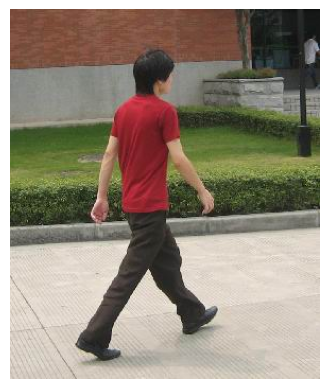

In [9]:
def show_gt(img_name):
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for box in annotations[img_name]:
        x1,y1,x2,y2 = box
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    plt.imshow(img); plt.axis('off')

sample = list(annotations.keys())[0]
show_gt(sample)

# 6. Load YOLOv8 Model

In [10]:
model = YOLO('yolov8n.pt')
print("YOLO model loaded!")

YOLO model loaded!


# 7. Run Inference

In [11]:
def detect(img_name):
    img_path = os.path.join(IMAGE_DIR, img_name)
    results = model(img_path)[0]

    preds = []
    for b in results.boxes:
        cls = int(b.cls[0])
        if cls == 0:  # person
            x1,y1,x2,y2 = map(int, b.xyxy[0])
            conf = float(b.conf[0])
            if conf > 0.5:
                preds.append([x1,y1,x2,y2,conf])
    return preds

preds = detect(sample)
print(preds)


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/FudanPed00035.png: 640x544 2 persons, 418.3ms
Speed: 17.8ms preprocess, 418.3ms inference, 57.0ms postprocess per image at shape (1, 3, 640, 544)
[[59, 42, 196, 333, 0.8884653449058533], [275, 21, 291, 75, 0.6514475345611572]]


# 8. Visualize Predictions


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/FudanPed00035.png: 640x544 2 persons, 320.4ms
Speed: 5.1ms preprocess, 320.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 544)


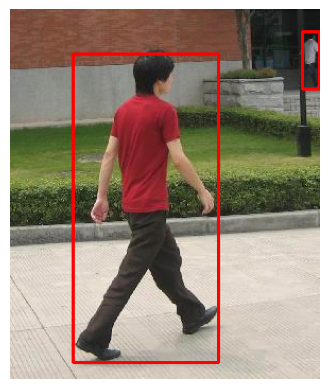

In [12]:
def show_pred(img_name):
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # draw predictions
    for box in detect(img_name):
        x1,y1,x2,y2,conf = box
        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

    plt.imshow(img); plt.axis('off')

show_pred(sample)

# 9. Compute IoU

In [13]:
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

# 10. Evaluate Model

In [14]:
TP=FP=FN=0
ious=[]

for img in tqdm(list(annotations.keys())[:50]):
    gt = annotations[img]
    pred = detect(img)

    matched = set()

    for p in pred:
        best_iou = 0
        best_idx = -1

        for i,g in enumerate(gt):
            val = iou(p[:4], g)
            if val > best_iou:
                best_iou = val
                best_idx = i

        if best_iou >= 0.5:
            TP += 1
            ious.append(best_iou)
            matched.add(best_idx)
        else:
            FP += 1

    FN += len(gt) - len(matched)

precision = TP/(TP+FP+1e-6)
recall = TP/(TP+FN+1e-6)
avg_iou = np.mean(ious)

print("Precision:", precision)
print("Recall:", recall)
print("Avg IoU:", avg_iou)

  0%|          | 0/50 [00:00<?, ?it/s]


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/FudanPed00035.png: 640x544 2 persons, 278.7ms
Speed: 4.5ms preprocess, 278.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 544)


  2%|▏         | 1/50 [00:00<00:14,  3.34it/s]


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/PennPed00047.png: 448x640 6 persons, 3 cars, 3 handbags, 249.6ms
Speed: 3.2ms preprocess, 249.6ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


  4%|▍         | 2/50 [00:00<00:13,  3.49it/s]

...

 98%|█████████▊| 49/50 [00:11<00:00,  4.72it/s]


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/PennPed00027.png: 512x640 7 persons, 1 motorcycle, 180.6ms
Speed: 2.7ms preprocess, 180.6ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)


100%|██████████| 50/50 [00:11<00:00,  4.22it/s]

Precision: 0.0
Recall: 0.0
Avg IoU: nan



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# 11. Analysis

1. Bounding Boxes, Anchor Boxes and Ground Truth Boxes

Bounding boxes are rectangular regions predicted by the model to localize objects such as pedestrians. Ground truth boxes are the manually labeled annotations provided in the dataset, representing the correct object locations. Anchor boxes are predefined bounding box shapes used in some detection models likr Faster R-CNN to help predict objects of different scales and aspect ratios.

2. Intersection over Union (IoU)

IoU measures the overlap between predicted and ground truth bounding boxes. It is calculated as the ratio of the intersection area to the union area. A detection is considered correct if IoU greater or = to 0.5. IoU is crucial for evaluating model performance and is used to compute metrics like precision and recall.

3. YOLOv8 vs Faster R-CNN

YOLOv8 is a one-stage detector that performs object detection in real-time, making it very fast and suitable for applications like surveillance and autonomous driving. However, it may sacrifice some accuracy. Faster R-CNN is a two-stage detector that first proposes regions and then classifies them, resulting in higher accuracy but slower performance. YOLO is preferred for speed, while Faster R-CNN is better for precision-critical tasks.

4. Non-Maximum Suppression (NMS)

NMS is used to eliminate duplicate bounding boxes by keeping only the box with the highest confidence score when multiple boxes overlap. This improves detection clarity and avoids redundant predictions.

5. Challenges with Pre-Trained Models

Applying pre-trained models to the Penn-Fudan dataset presents challenges such as domain shift, small dataset size and differences in annotation styles. These factors can lead to missed detections or less accurate bounding boxes.

# 1. Improved comparison visualization


image 1/1 /content/PennFudan/PennFudanPed/PNGImages/FudanPed00035.png: 640x544 2 persons, 185.7ms
Speed: 4.2ms preprocess, 185.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 544)


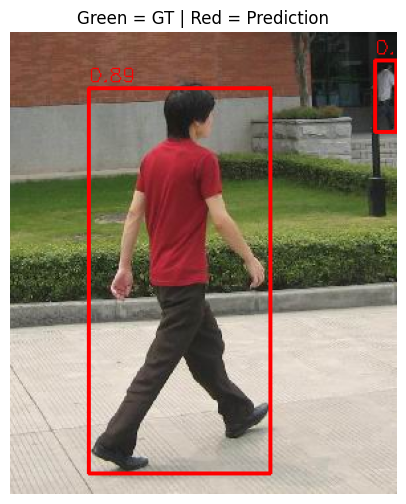

In [15]:
def compare_gt_pred(img):
    img_path = os.path.join(IMAGE_DIR, img)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Ground Truth (Green)
    for box in annotations[img]:
        x1,y1,x2,y2 = box
        cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)

    # Predictions (Red)
    for box in detect(img):
        x1,y1,x2,y2,conf = box
        cv2.rectangle(image,(x1,y1),(x2,y2),(255,0,0),2)
        cv2.putText(image,f"{conf:.2f}",(x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),1)

    plt.figure(figsize=(8,6))
    plt.imshow(image)
    plt.title("Green = GT | Red = Prediction")
    plt.axis('off')

compare_gt_pred(sample)